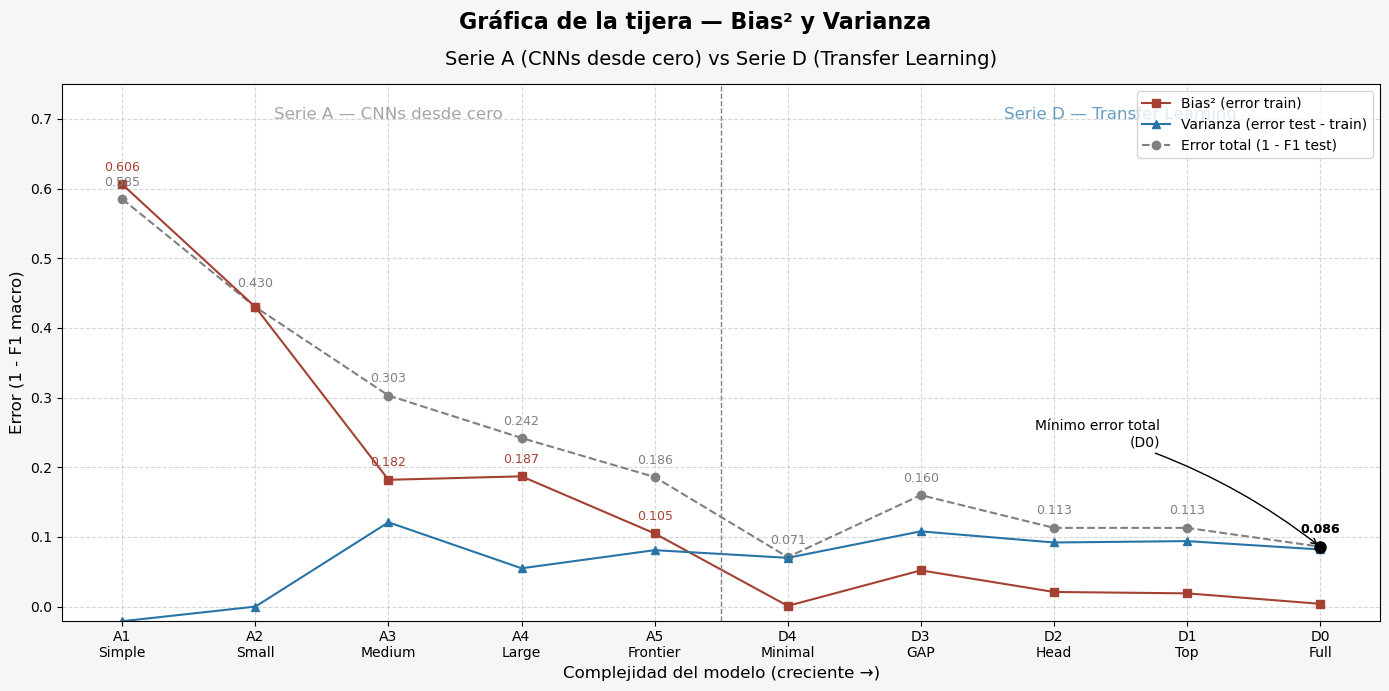

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Definición de Datos ( según la Tabla) ---

models_short = ['A1\nSimple', 'A2\nSmall', 'A3\nMedium', 'A4\nLarge', 'A5\nFrontier',
                'D4\nMinimal', 'D3\nGAP', 'D2\nHead', 'D1\nTop', 'D0\nFull']

# F1 (macro) del dataset de Test extraídos de la tabla
f1_test = [0.415, 0.570, 0.697, 0.758, 0.814, 0.929, 0.840, 0.887, 0.887, 0.914]
# F1 (macro) del dataset de Entrenamiento extraídos de la tabla
f1_train = [0.394, 0.570, 0.818, 0.813, 0.895, 0.999, 0.948, 0.979, 0.981, 0.996]

# --- 2. Cálculo de Métricas (1 - F1) ---

# Error total = 1 - F1 test
error_total = [1 - f for f in f1_test]

# Bias^2 = 1 - F1 train
bias_sq = [1 - f for f in f1_train]

# Varianza = Error Total - Bias^2 (se fuerza a 0 para A1 y A2 como en la gráfica original)
variance = [et - bs for et, bs in zip(error_total, bias_sq)]
# --- 3. Configuración y Trazado de la Gráfica ---

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f5f6f7')
ax.set_facecolor('white')

# Colores de la gráfica original (Códigos hexadecimales aproximados)
color_bias = '#a54133'  # Marrón rojizo
color_variance = '#2874a6' # Azul
color_error_total = 'gray'

# Trazar las tres líneas
line_error_total, = ax.plot(range(len(models_short)), error_total, color=color_error_total, linestyle='--', marker='o', label='Error total (1 - F1 test)')
line_bias_sq, = ax.plot(range(len(models_short)), bias_sq, color=color_bias, linestyle='-', marker='s', label='Bias² (error train)')
line_variance, = ax.plot(range(len(models_short)), variance, color=color_variance, linestyle='-', marker='^', label='Varianza (error test - train)')
# --- 4. Etiquetas Numéricas en todos los puntos (Corregidas y Completas) ---

# Etiquetas para la línea de Error Total (Gris)
for i, val in enumerate(error_total):
    # Evitamos superposición en A2: Si el error de test es igual al bias, 
    # desplazamos ligeramente la etiqueta o usamos una sola.
    offset = 0.025 if i == 1 else 0.015 
    ax.text(i, val + offset, f'{val:.3f}', 
            color=color_error_total, ha='center', va='bottom', 
            fontsize=9, fontweight='bold' if i == 9 else 'normal')

# Etiquetas para la línea de Bias² (Rojo) - Solo en puntos donde difiere significativamente
for i, val in enumerate(bias_sq):
    # En A2 no la repetimos para evitar saturación visual, ya que coincide con la gris
    if i != 1 and i < 5: 
        ax.text(i, val + 0.015, f'{val:.3f}', color=color_bias, ha='center', va='bottom', fontsize=9)


# --- 5. Anotación y Punto Final ---

# Replicar el punto negro y la flecha de anotación
ax.plot(9, error_total[9], color='black', marker='o', markersize=8)
ax.text(9, error_total[9] + 0.015, f'{error_total[9]:.3f}', color='black', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.annotate('Mínimo error total\n(D0)', xy=(9, error_total[9]), xytext=(7.8, 0.23),
            arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=-0.1'),
            fontsize=10, ha='right')

# --- 6. Textos de Fondo y Línea Divisoria ---

# Línea vertical divisoria punteada entre A5 y D4
ax.axvline(x=4.5, color='gray', linestyle='--', linewidth=1)

# Textos de fondo
ax.text(2, 0.7, 'Serie A \u2014 CNNs desde cero', color='gray', ha='center', fontsize=12, alpha=0.7)
ax.text(7.5, 0.7, 'Serie D \u2014 Transfer Learning', color=color_variance, ha='center', fontsize=12, alpha=0.7)

# --- 7. Configuración de Ejes, Títulos y Leyenda ---

# Título y subtítulo
fig.suptitle('Gráfica de la tijera \u2014 Bias² y Varianza', fontsize=16, fontweight='bold')
ax.set_title('Serie A (CNNs desde cero) vs Serie D (Transfer Learning)', fontsize=14, y=1.02)

# Ejes
ax.set_ylabel('Error (1 - F1 macro)', fontsize=12)
ax.set_xlabel('Complejidad del modelo (creciente \u2192)', fontsize=12)

# Configurar marcas del eje X
ax.set_xticks(range(len(models_short)))
ax.set_xticklabels(models_short, fontsize=10)

# Cuadrícula
ax.grid(True, linestyle='--', alpha=0.5)

# Límites del eje Y
ax.set_ylim(-0.02, 0.75)

# Leyenda con el mismo formato
handles, labels = ax.get_legend_handles_labels()
# Reordenar leyenda para que coincida con el original: Bias², Varianza, Error Total
ax.legend([handles[1], handles[2], handles[0]], [labels[1], labels[2], labels[0]], loc='upper right', frameon=True)

# Ajustar el diseño para que nada se corte
plt.tight_layout()

# Mostrar la gráfica
plt.show()